  imports all required libraries for Part 1.

In [11]:
import os
import json
import random
import numpy as np
import torch
import matplotlib.pyplot as plt

from collections import Counter, defaultdict
from sklearn.manifold import TSNE

## Part 1.1 TF-IDF Weighting

  reads cleaned text and builds article documents correctly.

In [12]:
def parse_cleaned_documents(text):
    #  parses cleaned.txt into article-level token lists.
    documents=[]
    current_tokens=[]

    for raw_line in text.splitlines():
        line=raw_line.strip()

        if line.startswith("Article Number:"):
            if len(current_tokens) > 0:
                documents.append(current_tokens)
                current_tokens=[]
            continue

        if line=="":
            continue

        if set(line)=={"="}:
            continue

        current_tokens.extend(line.split())

    if len(current_tokens) > 0:
        documents.append(current_tokens)

    return documents


with open("cleaned.txt", "r", encoding="utf-8") as file:
    cleaned_text=file.read()

docs=parse_cleaned_documents(cleaned_text)

print("Total documents:", len(docs))
if len(docs) > 0:
    print("Tokens in first document:", len(docs[0]))

Total documents: 229
Tokens in first document: 1672


  builds top 10000 vocabulary and maps other words to UNK.

In [13]:
def build_vocabulary(documents, max_vocab_size=10000):
    #  builds top-k vocabulary and keeps UNK token at index 0.
    all_tokens_local=[]
    for doc in documents:
        all_tokens_local.extend(doc)

    freq_local=Counter(all_tokens_local)
    top_words=[word for word, _ in freq_local.most_common(max_vocab_size)]

    vocab_local=["<UNK>"] + top_words
    word2idx_local={}
    idx2word_local={}

    for i in range(len(vocab_local)):
        word2idx_local[vocab_local[i]]=i
        idx2word_local[i]=vocab_local[i]

    return vocab_local, word2idx_local, idx2word_local, freq_local


def map_tokens_to_vocab(documents, word2idx_local):
    #  maps out-of-vocabulary words to UNK.
    mapped_documents=[]
    for doc in documents:
        mapped_doc=[]
        for token in doc:
            if token in word2idx_local:
                mapped_doc.append(token)
            else:
                mapped_doc.append("<UNK>")
        mapped_documents.append(mapped_doc)
    return mapped_documents


vocab, word2idx, idx2word, freq=build_vocabulary(docs, max_vocab_size=10000)
mapped_docs=map_tokens_to_vocab(docs, word2idx)

N=len(mapped_docs)
V=len(vocab)

print("Vocabulary size:", V)
print("Total documents for matrix:", N)
print("Top 10 frequent tokens:", freq.most_common(10))

Vocabulary size: 10001
Total documents for matrix: 229
Top 10 frequent tokens: [('کے', 16028), ('۔', 13365), ('کی', 10881), ('میں', 10862), ('کہ', 8360), ('ہے', 7704), ('سے', 7465), ('اور', 7061), ('کر', 5819), ('نے', 5680)]


  creates the term document frequency matrix from cleaned data.

In [14]:
def build_term_document_matrix(documents, word2idx_local):
    #  builds the term-document frequency matrix.
    term_doc=np.zeros((len(documents), len(word2idx_local)), dtype=np.float32)
    unk_index=word2idx_local["<UNK>"]

    for i in range(len(documents)):
        counts=Counter(documents[i])
        for word, count in counts.items():
            index=word2idx_local.get(word, unk_index)
            term_doc[i, index]=term_doc[i, index] + float(count)

    return term_doc


tf=build_term_document_matrix(mapped_docs, word2idx)

print("Term-document matrix shape:", tf.shape)
print("Non-zero term frequencies:", int(np.count_nonzero(tf)))

Term-document matrix shape: (229, 10001)
Non-zero term frequencies: 98300


  computes TF-IDF and saves tfidf_matrix.npy as required.

In [15]:
def compute_tfidf(term_doc):
    #  computes TF-IDF with N divided by 1 plus DF.
    doc_count=term_doc.shape[0]
    df_local=np.count_nonzero(term_doc > 0, axis=0).astype(np.float32)
    idf_local=np.log(doc_count / (1.0 + df_local))
    tfidf_local=term_doc * idf_local.reshape(1, -1)
    return tfidf_local, df_local


tfidf, df=compute_tfidf(tf)

np.save("tfidf_matrix.npy", tfidf)

print("TF-IDF matrix saved as tfidf_matrix.npy")
print("TF-IDF matrix shape:", tfidf.shape)
print("Document frequency non-zero count:", int(np.count_nonzero(df)))

TF-IDF matrix saved as tfidf_matrix.npy
TF-IDF matrix shape: (229, 10001)
Document frequency non-zero count: 10001


  reports top 10 discriminative words for each topic category.

In [16]:
def load_metadata(path_candidates):
    #  loads metadata from the first available JSON file.
    for path in path_candidates:
        if os.path.exists(path):
            with open(path, "r", encoding="utf-8") as file:
                data=json.load(file)
            print("Metadata loaded from:", path)
            return data
    print("Metadata file not found.")
    return {}


def infer_topic_from_title(title):
    #  infers a topic label from title keywords.
    text=title.lower()

    topic_keywords={
        "politics": ["سیاست", "حکومت", "وزیراعظم", "وزیر", "پارلیمنٹ", "الیکشن", "انتخاب", "عدالت", "پارٹی", "صدر", "government", "minister", "parliament", "election"],
        "sports": ["کرکٹ", "میچ", "ٹیم", "کھلاڑی", "کپ", "اسپورٹس", "رنز", "match", "team", "player", "cricket", "score"],
        "economy": ["معیشت", "مہنگائی", "بینک", "بجٹ", "تجارت", "قیمت", "ٹیکس", "ڈالر", "bank", "budget", "trade", "inflation", "gdp"],
        "international": ["عالمی", "بین الاقوامی", "اقوام متحدہ", "بھارت", "انڈیا", "امریکہ", "چین", "روس", "foreign", "bilateral", "treaty", "un"],
        "health_society": ["صحت", "ہسپتال", "بیماری", "ویکسین", "تعلیم", "سیلاب", "سماج", "hospital", "disease", "vaccine", "education", "flood"]
    }

    best_topic="other"
    best_score=0

    for topic, keywords in topic_keywords.items():
        score=0
        for keyword in keywords:
            if keyword in text:
                score=score + 1
        if score > best_score:
            best_score=score
            best_topic=topic

    return best_topic


def build_doc_topics(metadata_dict, doc_count):
    #  creates one topic label for each document.
    labels=[]
    for i in range(doc_count):
        key=str(i + 1)
        if key in metadata_dict and isinstance(metadata_dict[key], dict):
            title=metadata_dict[key].get("title", "")
            labels.append(infer_topic_from_title(title))
        else:
            labels.append("other")
    return labels


def report_top_tfidf_words_by_topic(tfidf_matrix, labels, idx2word_local, top_k=10):
    #  prints top-k discriminative words for each topic.
    V_local=tfidf_matrix.shape[1]
    topic_scores=defaultdict(lambda: np.zeros(V_local, dtype=np.float64))
    topic_counts=defaultdict(int)

    for i in range(len(labels)):
        topic=labels[i]
        topic_scores[topic]=topic_scores[topic] + tfidf_matrix[i]
        topic_counts[topic]=topic_counts[topic] + 1

    for topic in sorted(topic_scores.keys()):
        scores=topic_scores[topic] / max(1, topic_counts[topic])
        scores[0]=-1.0
        top_indices=np.argsort(scores)[-top_k:][::-1]

        print("\nTopic:", topic)
        print("Documents in topic:", topic_counts[topic])
        print("Top words:")
        for idx in top_indices:
            print(idx2word_local[int(idx)])

    return topic_scores


metadata=load_metadata(["Metadata.json", "articles_metadata.json"])
doc_topics=build_doc_topics(metadata, N)
category_scores=report_top_tfidf_words_by_topic(tfidf, doc_topics, idx2word, top_k=10)

print("\nTopic counts:", Counter(doc_topics))

Metadata loaded from: articles_metadata.json

Topic: economy
Documents in topic: 4
Top words:
کیکٹس
پود
کوپیاپوا
نجکار
پودے
جنس
پیومبیٹ
ائ
خواہش
کیکٹ

Topic: health_society
Documents in topic: 2
Top words:
تارکین
وینزویلا
گیپ
ڈیرین
وطن
ڈاکٹر
جنگل
ہیٹ
ٹونٹ
کنڈیشنز

Topic: international
Documents in topic: 37
Top words:
اسرائیل
ایپسٹین
بنگلہ
اریجیت
دیش
مجیب
انڈیا
طیارے
افغانست
ٹرمپ

Topic: other
Documents in topic: 143
Top words:
انڈیا
دیش
بنگلہ
اے
بجل
پی
سولر
ٹی
خان
ایپسٹین

Topic: politics
Documents in topic: 26
Top words:
ایپسٹین
لیاقت
عراق
اخونزادہ
سفارت
دادا
قتل
خا
بل
پولیس

Topic: sports
Documents in topic: 17
Top words:
کھلاڑ
ٹیم
کرکٹ
عثم
کروڑ
ٹیکسٹائل
نیلام
طارق
فارمیٹ
روس

Topic counts: Counter({'other': 143, 'international': 37, 'politics': 26, 'sports': 17, 'economy': 4, 'health_society': 2})


## Part 1.2 PPMI and t-SNE

  builds the co-occurrence matrix with symmetric window size 5.

In [17]:
def build_cooccurrence_matrix(documents, word2idx_local, window_size=5):
    #  builds a symmetric co-occurrence matrix with fixed window.
    vocab_size=len(word2idx_local)
    cooc_local=np.zeros((vocab_size, vocab_size), dtype=np.float32)
    unk_index=word2idx_local["<UNK>"]

    for d in range(len(documents)):
        doc=documents[d]
        indices=[]
        for token in doc:
            indices.append(word2idx_local.get(token, unk_index))

        length=len(indices)

        for i in range(length):
            center=indices[i]
            left=max(0, i - window_size)
            right=min(length, i + window_size + 1)

            for j in range(left, right):
                if i != j:
                    context=indices[j]
                    cooc_local[center, context]=cooc_local[center, context] + 1.0

        if (d + 1) % 25==0:
            print("Processed documents:", d + 1)

    return cooc_local


window_size=5
cooc=build_cooccurrence_matrix(mapped_docs, word2idx, window_size=window_size)

print("Co-occurrence matrix shape:", cooc.shape)
print("Non-zero co-occurrence entries:", int(np.count_nonzero(cooc)))

Processed documents: 25
Processed documents: 50
Processed documents: 75
Processed documents: 100
Processed documents: 125
Processed documents: 150
Processed documents: 175
Processed documents: 200
Processed documents: 225
Co-occurrence matrix shape: (10001, 10001)
Non-zero co-occurrence entries: 852129


  computes PPMI weights and saves ppmi_matrix.npy as required.

In [18]:
def compute_ppmi(cooc_matrix):
    #  converts co-occurrence counts to PPMI scores.
    total=float(np.sum(cooc_matrix))
    row_sum=np.sum(cooc_matrix, axis=1)
    col_sum=np.sum(cooc_matrix, axis=0)

    ppmi_local=np.zeros_like(cooc_matrix, dtype=np.float32)

    nz_i, nz_j=np.nonzero(cooc_matrix)
    values=cooc_matrix[nz_i, nz_j]
    denom=row_sum[nz_i] * col_sum[nz_j]

    safe=denom > 0
    nz_i=nz_i[safe]
    nz_j=nz_j[safe]
    values=values[safe]
    denom=denom[safe]

    pmi_values=np.log2((values * total) / denom)
    pmi_values=np.maximum(pmi_values, 0.0)

    ppmi_local[nz_i, nz_j]=pmi_values.astype(np.float32)

    return ppmi_local


ppmi=compute_ppmi(cooc)

np.save("ppmi_matrix.npy", ppmi)

print("PPMI matrix saved as ppmi_matrix.npy")
print("PPMI shape:", ppmi.shape)
print("PPMI non-zero values:", int(np.count_nonzero(ppmi)))

PPMI matrix saved as ppmi_matrix.npy
PPMI shape: (10001, 10001)
PPMI non-zero values: 716194


  makes the 2D t-SNE plot of 200 frequent tokens with legend.

Semantic categories with centroids: ['politics', 'sports', 'geography', 'economy', 'health']
Words in t-SNE: 200
Category counts in plot: Counter({'geography': 146, 'politics': 22, 'sports': 20, 'economy': 10, 'health': 2})


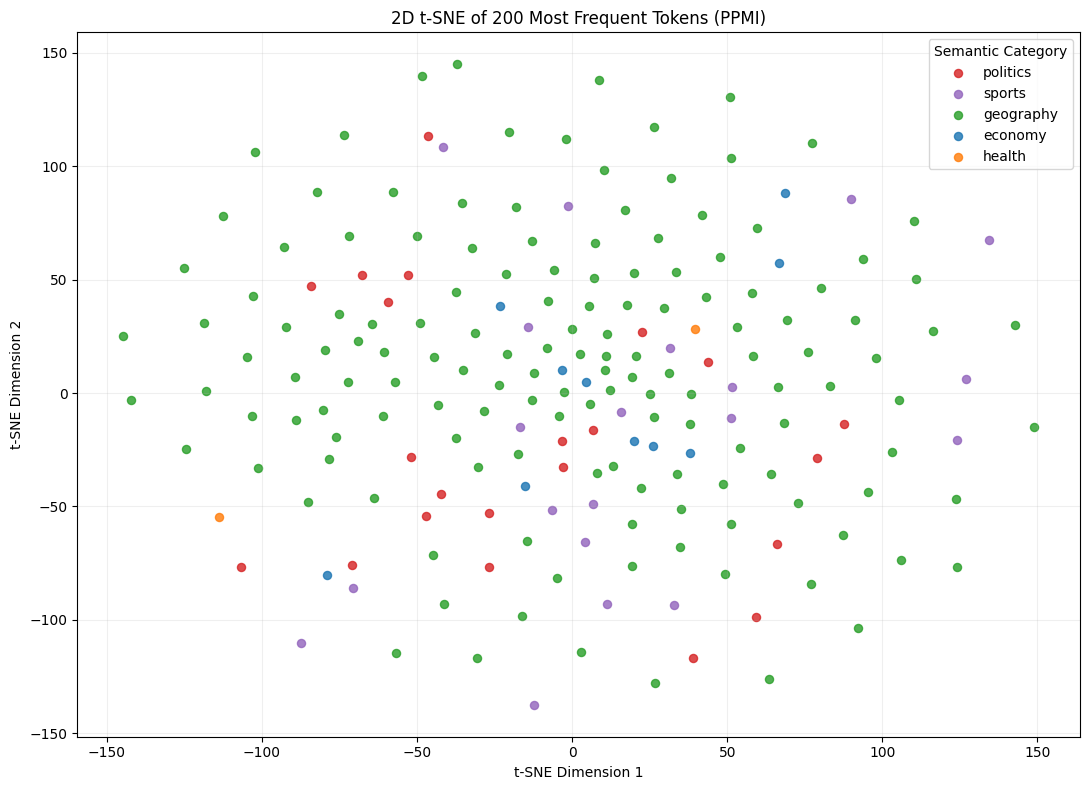

In [19]:
def cosine_similarity_for_category(vec_a, vec_b):
    #  computes cosine similarity for semantic category matching.
    denom=(np.linalg.norm(vec_a) * np.linalg.norm(vec_b)) + 1e-12
    return float(np.dot(vec_a, vec_b) / denom)


def build_category_centroids(matrix, word2idx_local):
    #  builds category centroids from anchor words.
    seed_words={
        "politics": ["حکومت", "وزیر", "عدالت", "پارلیمنٹ", "الیکشن", "پارٹی"],
        "sports": ["کرکٹ", "ٹیم", "میچ", "کھلاڑ", "کپ", "رن"],
        "geography": ["پاکستان", "انڈیا", "بھارت", "چین", "روس", "دنیا", "ملک", "شہر", "صوبہ"],
        "economy": ["معیشت", "بینک", "بجٹ", "تجارت", "مہنگائی", "ڈالر"],
        "health": ["صحت", "تعلیم", "ہسپتال", "بیماری", "ویکسین", "سیلاب"]
    }

    centroids={}

    for category in seed_words:
        vectors=[]
        for word in seed_words[category]:
            if word in word2idx_local:
                index=word2idx_local[word]
                vec=matrix[index]
                if np.linalg.norm(vec) > 0:
                    vectors.append(vec)

        if len(vectors) > 0:
            centroids[category]=np.mean(np.array(vectors), axis=0)

    return centroids


def infer_semantic_category_for_word(word, matrix, word2idx_local, centroids):
    #  assigns the nearest semantic category centroid to a token.
    if word not in word2idx_local:
        return "other"

    if len(centroids)==0:
        return "other"

    word_vector=matrix[word2idx_local[word]]

    if np.linalg.norm(word_vector)==0:
        return "other"

    best_category="other"
    best_score=-1.0

    for category in centroids:
        centroid=centroids[category]
        score=cosine_similarity_for_category(word_vector, centroid)
        if score > best_score:
            best_score=score
            best_category=category

    return best_category


def build_color_map():
    return {
        "politics": "tab:red",
        "sports": "tab:purple",
        "geography": "tab:green",
        "economy": "tab:blue",
        "health": "tab:orange",
        "other": "tab:gray"
    }


category_centroids=build_category_centroids(ppmi, word2idx)
print("Semantic categories with centroids:", list(category_centroids.keys()))

top_200_words=[]
for word, _ in freq.most_common(200):
    if word in word2idx and word != "<UNK>":
        top_200_words.append(word)

if len(top_200_words) > 200:
    top_200_words=top_200_words[:200]

plot_vectors=[]
semantic_labels=[]

for word in top_200_words:
    idx=word2idx[word]
    vec=ppmi[idx].astype(np.float32)

    if np.linalg.norm(vec)==0:
        vec=vec + np.full_like(vec, 1e-9)

    plot_vectors.append(vec)
    semantic_labels.append(infer_semantic_category_for_word(word, ppmi, word2idx, category_centroids))

plot_vectors=np.array(plot_vectors, dtype=np.float32)

print("Words in t-SNE:", len(top_200_words))
print("Category counts in plot:", Counter(semantic_labels))

if len(top_200_words) >= 5:
    perplexity_value=min(30, max(5, len(top_200_words) // 10))

    tsne=TSNE(
        n_components=2,
        random_state=42,
        perplexity=perplexity_value,
        init="pca",
        learning_rate="auto"
    )

    points=tsne.fit_transform(plot_vectors)

    color_map=build_color_map()
    ordered_labels=["politics", "sports", "geography", "economy", "health", "other"]
    unique_labels=[]

    for label in ordered_labels:
        if label in set(semantic_labels):
            unique_labels.append(label)

    plt.figure(figsize=(11, 8))

    for label in unique_labels:
        indices=[]
        for i in range(len(semantic_labels)):
            if semantic_labels[i]==label:
                indices.append(i)

        x_vals=[points[i, 0] for i in indices]
        y_vals=[points[i, 1] for i in indices]

        plt.scatter(x_vals, y_vals, c=color_map[label], label=label, s=34, alpha=0.82)

    plt.title("2D t-SNE of 200 Most Frequent Tokens (PPMI)")
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.legend(title="Semantic Category")
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()


  prints top 5 nearest neighbors for at least 10 query words.

In [20]:
def cosine_similarity(vec_a, vec_b):
    #  computes cosine similarity between two vectors.
    denom=(np.linalg.norm(vec_a) * np.linalg.norm(vec_b)) + 1e-12
    return float(np.dot(vec_a, vec_b) / denom)


def top_k_neighbors(query_word, matrix, word2idx_local, idx2word_local, k=5):
    #  returns top-k nearest neighbors by cosine similarity.
    if query_word not in word2idx_local:
        return []

    query_idx=word2idx_local[query_word]
    query_vec=matrix[query_idx]

    if np.linalg.norm(query_vec)==0:
        return []

    similarities=[]

    for j in range(matrix.shape[0]):
        if j==query_idx:
            continue

        candidate_vec=matrix[j]
        if np.linalg.norm(candidate_vec)==0:
            continue

        score=cosine_similarity(query_vec, candidate_vec)
        similarities.append((score, j))

    similarities.sort(key=lambda x: x[0], reverse=True)

    neighbors=[]
    for score, index in similarities:
        word=idx2word_local[index]
        if word=="<UNK>":
            continue
        neighbors.append((word, score))
        if len(neighbors)==k:
            break

    return neighbors


query_candidates=["پاکستان", "حکومت", "عدالت", "معیشت", "فوج", "صحت", "تعلیم", "آبادی", "کرکٹ", "انڈیا", "وزیر", "بینک"]

query_words=[]
for word in query_candidates:
    if word in word2idx and word not in query_words:
        query_words.append(word)

if len(query_words) < 10:
    for word, _ in freq.most_common(300):
        if word in word2idx and word != "<UNK>" and word not in query_words:
            query_words.append(word)
        if len(query_words) >= 10:
            break

query_words=query_words[:10]

print("Query words used:", query_words)

for word in query_words:
    print("\nWord:", word)
    neighbors=top_k_neighbors(word, ppmi, word2idx, idx2word, k=5)

    if len(neighbors)==0:
        print("No neighbors found")
    else:
        for neighbor_word, score in neighbors:
            print(neighbor_word, round(score, 4))

Query words used: ['حکومت', 'عدالت', 'معیشت', 'فوج', 'صحت', 'تعلیم', 'کرکٹ', 'انڈیا', 'وزیر', 'بینک']

Word: حکومت
طالب 0.2259
جانب 0.148
افغ 0.1425
کے 0.1389
کی 0.1362

Word: عدالت
جج 0.2476
چٹھہ 0.2217
سماعت 0.1706
ملزم 0.1689
کورٹ 0.1632

Word: معیشت
دیکھیے 0.2476
معاش 0.1821
بسواجیت 0.1805
بحال 0.1703
نوش 0.1652

Word: فوج
بغاوت 0.1683
انڈین 0.1682
افسر 0.1654
پاکستا 0.1555
افواج 0.1449

Word: صحت
یاب 0.2364
تولید 0.2267
پاؤلا 0.2112
مند 0.2104
جنس 0.2058

Word: تعلیم
ہائر 0.21
سیکنڈر 0.175
نیٹسال 0.1723
سوازگ 0.1666
قابلیت 0.1657

Word: کرکٹ
کھیل 0.2588
بورڈ 0.219
کھلاڑ 0.1742
کپ 0.1689
ٹیم 0.1673

Word: انڈیا
دیش 0.1903
بنگلہ 0.1871
پاکست 0.1737
کے 0.1612
انڈین 0.1549

Word: وزیر
اعظم 0.4395
داخلہ 0.2932
خارجہ 0.2839
وفاق 0.2462
سابق 0.2298

Word: بینک
اسپارکاسے 0.2259
الارم 0.1867
فائٹرز 0.1752
المنزلہ 0.1733
فائر 0.1584
